## Imports

In [1]:
import os
import numpy as np
import MDAnalysis as mda
from MDAnalysis.coordinates.memory import MemoryReader
from ase.io.trajectory import Trajectory

import matplotlib.pyplot as plt

from mdcraft.analysis.transport import Onsager

# Import the byteff2 ASE backend directly from compute.py (no copy/paste).
import importlib.util
from pathlib import Path

_COMPUTE_PY = Path("/global/homes/y/yuejian/project/MLFF-distill/APPLICATIONS/"
                   "electrolytes/observable_scripts/conductivity/compute.py")
_COMPUTE_PY_2 = Path("/global/homes/y/yuejian/project/MLFF-distill/APPLICATIONS/electrolytes/observable_scripts/mean_square_displacement/msd_with_com.py")
_COMPUTE_PY_3 = Path("/global/homes/y/yuejian/project/MLFF-distill/APPLICATIONS/electrolytes/observable_scripts/mean_square_displacement/utils/component_dictionary.py")

_spec = importlib.util.spec_from_file_location("elyte_conductivity_compute", _COMPUTE_PY)
_spec_2 = importlib.util.spec_from_file_location("elyte_msd_compute", _COMPUTE_PY_2)
_spec_3 = importlib.util.spec_from_file_location("elyte_component_dictionary", _COMPUTE_PY_3)

_elyte_compute = importlib.util.module_from_spec(_spec)
_elyte_compute_2 = importlib.util.module_from_spec(_spec_2)
_elyte_compute_3 = importlib.util.module_from_spec(_spec_3)
_spec.loader.exec_module(_elyte_compute)   # runs compute.py's __file__-based path setup
_spec_2.loader.exec_module(_elyte_compute_2)   # runs compute.py's __file__-based path setup
_spec_3.loader.exec_module(_elyte_compute_3)   # runs compute.py's __file__-based path setup
# Bind the ASE-backend entry points + species dicts into the notebook namespace.
run_onsager_conductivity  = _elyte_compute.run_onsager_conductivity
run_conductivity_analysis = _elyte_compute.run_conductivity_analysis
cation_dict  = _elyte_compute.cation_dict
anion_dict   = _elyte_compute.anion_dict
solvent_dict = _elyte_compute.solvent_dict
loaded_unwrapped = _elyte_compute._load_unwrapped
direct_groups_from_species = _elyte_compute_2.direct_groups_from_species
avg_cell = _elyte_compute._average_cell
cation_dict = _elyte_compute_3.cation_dict
anion_dict = _elyte_compute_3.anion_dict
solvent_dict = _elyte_compute_3.solvent_dict


/pscratch/sd/y/yuejian/envs/fairchemV2_new/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [2]:
OUTDIR = "/global/u1/y/yuejian/project/MLFF-distill/draft/conductivity"
REF_CSV = ("/global/homes/y/yuejian/project/MLFF-distill/m5250/distillation_proj/"
           "simulation_results/PAINN/electrolytes_data/analysis/20ns_fp32/npt/"
           "group_results/conductivity/conductivity_parity_painn_npt_gt0p1M.csv")

SYSTEMS = {
    "naotf_dme": {
        "traj": "/global/u1/y/yuejian/project/MLFF-distill/m5250/distillation_proj/"
                "simulation_results/PAINN/electrolytes_data/simulation/naotf_dme/"
                "npt_1M_298K_2ns_100fs/npt_1M_298K_2ns_100fs.traj",
        "anion_central": "S", "anion": "OTf$^-$", "ref_key": "naotf_dme npt 1.0M 298K",
    },
    "napf6_dme": {
        "traj": "/global/u1/y/yuejian/project/MLFF-distill/m5250/distillation_proj/"
                "simulation_results/PAINN/electrolytes_data/simulation/napf6_dme/"
                "npt_1M_298K_2ns_100fs/npt_1M_298K_2ns_100fs.traj",
        "anion_central": "P", "anion": "PF$_6^-$", "ref_key": "napf6_dme npt 1.0M 298K",
    },
}

TEMPERATURE_K = 298.0
FRAME_DT_PS = 0.1                         # 100 fs between stored frames
STRIDE = 100                               # -> 1.0 ps spacing, 20000 frames
# Diffusive-regime fit windows (ns). First is primary; second is a tighter
# window to gauge sensitivity to the noisy long-time tail.
WINDOWS = {"1-10ns": (1.0, 2.0), "2-8ns": (2.0, 3.0)}
MAIN_WIN = "1-10ns"
NDIM = 3

KAPPA_TO_SI = 1.0e19                      # mdcraft kappa unit -> S/m
SI_TO_USCM = 1.0e4                        # S/m -> uS/cm
D_TO_CM2_S = 1.0e-4                       # A^2/ps -> cm^2/s

In [3]:
# Map the two notebook systems to byteff2 species-dictionary keys.
BYTEFF2_SPECIES = {
    "naotf_dme": dict(cat_symbol="Na", anion_symbol="OTf", solvent_symbol="DME"),
    "napf6_dme": dict(cat_symbol="Na", anion_symbol="PF6", solvent_symbol="DME"),
}

# byteff2 fit settings (defaults reproduce the reference-code Onsager `ref_ons`).
# For a 1-10 ns lag window matching mdcraft: nt_start=100, nt_end=1000.
BYTEFF2_KW = dict(eq_cut_ns=2.0, load_dt_ps=10.0, nt_start=50, nt_end=200,
                  max_traj_ns=20.0, viscosity_cP=1.0)

byteff2_results = {}
for name, cfg in SYSTEMS.items():
    print(f"\n{'='*64}\nbyteff2 Onsager: {name}\n{'='*64}")
#     res = run_onsager_conductivity(
#         cfg["traj"], dt_fs=FRAME_DT_PS * 1000.0, T_K=TEMPERATURE_K,
#         **BYTEFF2_SPECIES[name], **BYTEFF2_KW,
#     )
#     byteff2_results[name] = res
#     print(f"  sigma_onsager = {res['sigma_onsager_mS_cm']:.4f} mS/cm "
#           f"({res['sigma_onsager_mS_cm']*1e3:.0f} uS/cm)")
#     print(f"  sigma_NE      = {res['sigma_NE_mS_cm']:.4f} mS/cm "
#           f"({res['sigma_NE_mS_cm']*1e3:.0f} uS/cm)")
#     print(f"  Dself [1e-10 m2/s] {res['species_order']} = "
#           f"{[round(d, 3) for d in res['Dself_1e10_m2s']]}")
#     print(f"  fit lag = [{res['fit_lag_start_ns']:.2f}, {res['fit_lag_end_ns']:.2f}] ns"
#           f"   V = {res['V_angstrom3']:.0f} A^3")


byteff2 Onsager: naotf_dme

byteff2 Onsager: napf6_dme


In [4]:
traj_path = "/global/homes/y/yuejian/project/MLFF-distill/m5250/distillation_proj/simulation_results/PAINN/electrolytes_data/simulation/FP32_simulation/In_distribution_exp/NPT_langevin/npt_replica_0/naotf_dme/npt_0_1M_298K_2ns_100fs/npt_0_1M_298K_2ns_100fs.traj"

cat_symbol = "Na"
anion_symbol = "OTf"
solvent_symbol = "DME"
anion_central = "S"          # central heavy atom of the anion (S for OTf, P for PF6)

cat_symbol_list = cation_dict[cat_symbol]
anion_symbol_list = anion_dict[anion_symbol]
solvent_symbol_list = solvent_dict[solvent_symbol]

with Trajectory(str(traj_path)) as trj:
    symbols0 = np.array(trj[0].get_chemical_symbols())
    cell = trj[0].cell.array
cat_groups = direct_groups_from_species(symbols0, cat_symbol_list)
anion_groups = direct_groups_from_species(symbols0, anion_symbol_list)
solvent_groups = direct_groups_from_species(symbols0, solvent_symbol_list)

dims = avg_cell(traj_path, 199900, 200000)
# print(cell)
reorder_idx = (
        [int(i) for g in cat_groups    for i in g] +
        [int(i) for g in anion_groups  for i in g] +
        [int(i) for g in solvent_groups for i in g]
    )

# positions = loaded_unwrapped(traj_path, reorder_idx, 
#                             stride = 10, 
#                             i_start = 0, 
#                             i_end = 200000)
# dt_ps = 1
# print("finished loading")

In [5]:
# COM checker
# ── COM drift checker (uses the unwrapped full-system `positions`) ────────────
with Trajectory(str(traj_path)) as trj:
    masses0 = trj[0].get_masses()              # (n_atoms,) original order
masses_re = masses0[reorder_idx]               # reorder to match positions' atom axis
M = masses_re.sum()

R = np.einsum("tnj,n->tj", positions, masses_re) / M   # (T,3) system COM per frame
drift = R - R[0]                                       # displacement from frame 0
dr = np.linalg.norm(drift, axis=1)                     # |R(t)-R(0)|

print(f"atoms in COM   : {len(masses_re)}  (full system, incl. solvent)")
print(f"COM net drift  : {dr[-1]:.2f} A   per-axis {drift[-1].round(2)}")
print(f"COM max excursion : {dr.max():.2f} A")

t_ns = np.arange(len(R)) * dt_ps / 1000.0
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for k, lab in enumerate("xyz"):
    ax[0].plot(t_ns, drift[:, k], label=f"COM {lab}")
ax[0].axhline(0, color="grey", lw=0.5)
ax[0].set(xlabel="t (ns)", ylabel="COM displacement (A)", title="system COM drift (unwrapped)")
ax[0].legend()
ax[1].plot(t_ns, dr, color="k")
ax[1].set(xlabel="t (ns)", ylabel="|R(t)-R(0)| (A)", title="COM excursion magnitude")
fig.tight_layout(); plt.show()

NameError: name 'positions' is not defined

In [ ]:
# vacf checker
with Trajectory(str(traj_path)) as trj:
    momentums = trj[0].get_velocities()              # (n_atoms,) original order

[2000 2001 2003 2011] 2 2 [0, 1] [3, 11]


reading velocities: 100%|██████████| 80000/80000 [03:14<00:00, 411.76it/s]


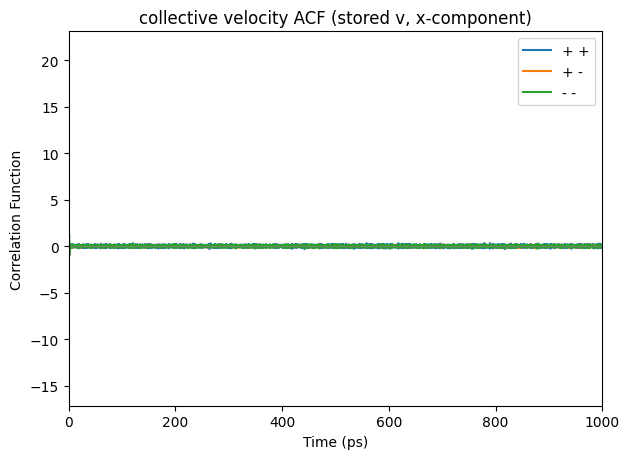

In [6]:
# ── VACF checker: collective velocity ACF from STORED velocities ──────────────
# Use the velocities written in every frame (get_velocities) instead of
# finite-differencing positions. compute_acf (from the transport-coefficients
# submodule, imported with the same importlib pattern as compute.py) wants the
# velocity SUMMED over all cations and over all anions, each (n_times, 3); it
# returns 3 arrays (++, +-, --), each (n_times, 3).
import importlib.util
from pathlib import Path
import ase.units as ase_u
from tqdm import tqdm

_LIJ_PY = Path("/global/homes/y/yuejian/project/MLFF-distill/submodule/"
               "transport-coefficients/example_calculation/lij_analysis.py")
_spec_lij = importlib.util.spec_from_file_location("lij_analysis", _LIJ_PY)
_lij = importlib.util.module_from_spec(_spec_lij)
_spec_lij.loader.exec_module(_lij)
TransportCoefficients = _lij.TransportCoefficients

# --- frame sampling (match the position-loading cell: stride 10 -> 1 ps) ------
STRIDE_V, I_START_V, I_END_V = 1, 0, 80000   # shrink I_END_V for a quick check
REMOVE_COM_VEL = True                           # subtract mass-weighted system-COM velocity
dt_ps_vacf = STRIDE_V * FRAME_DT_PS             # 10 * 0.1 = 1.0 ps

# ion-site columns within the reordered system, then map to ORIGINAL-order idx
na_cols, an_cols, col = [], [], 0
for g in cat_groups:                            # Na is monoatomic -> group == site
    na_cols.append(col); col += len(g)
for g in anion_groups:                          # central heavy atom of each anion
    local = int(np.where(symbols0[g] == anion_central)[0][0])
    an_cols.append(col + local); col += len(g)
n_na, n_an = len(na_cols), len(an_cols)
reorder_arr  = np.asarray(reorder_idx)
ion_orig_idx = reorder_arr[na_cols + an_cols]   # original-order idx of ion sites (cat, then an)
print(ion_orig_idx,n_na,n_an,na_cols,an_cols)
# --- stream stored velocities (-> A/ps), summed per species -------------------
frame_idxs = list(range(I_START_V, I_END_V, STRIDE_V))
T = len(frame_idxs)
VEL_A_PER_PS = ase_u.fs * 1e3                    # ASE velocity unit -> A/ps (~98.2)
v_cation = np.zeros((T, 3))
v_anion  = np.zeros((T, 3))
with Trajectory(str(traj_path)) as trj:
    masses_all = trj[frame_idxs[0]].get_masses()
    Mtot = masses_all.sum()
    for k, fi in enumerate(tqdm(frame_idxs, desc="reading velocities")):
        v = trj[fi].get_velocities() * VEL_A_PER_PS          # (n_atoms, 3), original order
        if REMOVE_COM_VEL:
            v = v - (masses_all[:, None] * v).sum(0) / Mtot  # barycentric (kills Langevin drift)
        vi = v[ion_orig_idx]                                 # (n_na+n_an, 3)
        v_cation[k] = vi[:n_na].sum(0)                       # sum over all cations
        v_anion[k]  = vi[n_na:].sum(0)                       # sum over all anions

# --- correlation functions via the submodule's compute_acf --------------------
tc = TransportCoefficients(v_cation_filename=None, v_anion_filename=None,
                           V=1.0, times=None, T=TEMPERATURE_K)
acf_plusplus, acf_plusminus, acf_minusminus = tc.compute_acf(v_cation, v_anion)
times = np.arange(acf_plusplus.shape[0]) * dt_ps_vacf       # ps

# --- plot (x-component), same style as the reference snippet -------------------
plt.figure(figsize=(6.4, 4.7))
plt.plot(times, acf_plusplus[:, 0],   label="+ +")
plt.plot(times, acf_plusminus[:, 0],  label="+ -")
plt.plot(times, acf_minusminus[:, 0], label="- -")
plt.axhline(0, color="grey", lw=0.6)
plt.xlim(0, min(1000, times[-1]))
# plt.ylim(-0.0002, 0.0002)   # fixed scale from the snippet; units here = (A/ps)^2
plt.legend()
plt.ylabel("Correlation Function")
plt.xlabel("Time (ps)")
plt.title("collective velocity ACF (stored v, x-component)")
plt.tight_layout()
plt.show()


In [36]:
v_cation.shape, v_anion.shape,v_cation

((80000, 3),
 (80000, 3),
 array([[-2.32356685,  7.06902681,  2.44078706],
        [-2.29345672,  5.68062545, -7.40116811],
        [ 2.21660441, -3.85943304,  3.44527567],
        ...,
        [ 4.6987435 ,  2.01638411, -0.61723742],
        [-4.72044291, -4.65005035,  1.19207099],
        [ 1.49039226, -1.45835803, -4.06938864]], shape=(80000, 3)))

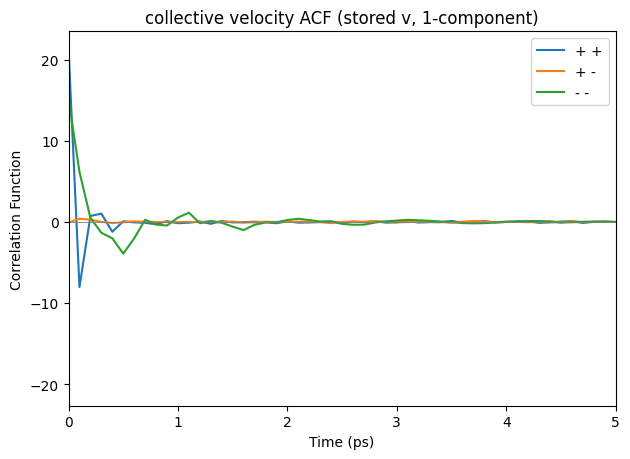

In [7]:
# --- correlation functions via the submodule's compute_acf --------------------
tc = TransportCoefficients(v_cation_filename=None, v_anion_filename=None,
                           V=1.0, times=None, T=TEMPERATURE_K)
acf_plusplus, acf_plusminus, acf_minusminus = tc.compute_acf(v_cation, v_anion)
times = np.arange(acf_plusplus.shape[0]) * dt_ps_vacf       # ps

# --- plot (x-component), same style as the reference snippet -------------------
plt.figure(figsize=(6.4, 4.7))
dim = 1
plt.plot(times, acf_plusplus[:, dim],   label="+ +")
plt.plot(times, acf_plusminus[:, dim],  label="+ -")
plt.plot(times, acf_minusminus[:, dim], label="- -")
plt.axhline(0, color="grey", lw=0.6)
plt.xlim(0, times[50])
# plt.ylim(-0.0002, 0.0002)   # fixed scale from the snippet; units here = (A/ps)^2
plt.legend()
plt.ylabel("Correlation Function")
plt.xlabel("Time (ps)")
plt.title("collective velocity ACF (stored v, {}-component)".format(dim))
plt.tight_layout()
plt.show()

In [7]:
# in-memory MDAnalysis Universe of the ion sites (cations first, then anions)
n_at = ion_pos.shape[1]
u = mda.Universe.empty(n_at, n_residues=n_at,
                       atom_resindex=np.arange(n_at), trajectory=True)
u.add_TopologyAttr("name", ["NA"] * n_na + ["AN"] * n_an)
u.load_new(ion_pos.astype(np.float32), format=MemoryReader)
# ─────────────────────────────────────────────────────────────────────────────


ons = Onsager([u.atoms[:n_na], u.atoms[n_na:]], groupings="atoms",
                  temperature=TEMPERATURE_K, charges=[1.0, -1.0],
                  dimensions=dims, dt= dt_ps, unwrap=False, center=False,
                  fft=True, verbose=False)
ons.run()

In [8]:
# ── remove system center-of-mass (COM) drift ─────────────────────────────────
# The Langevin thermostat lets the whole-system COM random-walk. That common
# drift cancels in kappa (electroneutral) but inflates single-ion MSDs (Dself,
# t+/-). Work in the barycentric frame  r_i(t) - R(t),  with R = mass-weighted
# COM over ALL atoms (solvent included). `positions` is the full reordered
# system and is already PBC-unwrapped, so R(t) is well defined.
with Trajectory(str(traj_path)) as trj:
    masses0 = trj[0].get_masses()                   # (n_atoms,) original order
masses_re = masses0[reorder_idx]                    # reorder to match positions' atom axis
M = masses_re.sum()

R = np.einsum("tnj,n->tj", positions, masses_re) / M     # (T,3) system COM per frame
drift = np.linalg.norm(R - R[0], axis=1)
print(f"system-COM drift : net {drift[-1]:.2f} A   max {drift.max():.2f} A   "
      f"({len(masses_re)} atoms incl. solvent)")

ion_pos_c = ion_pos - R[:, None, :]                 # COM-removed ion sites (T, n_na+n_an, 3)

# keep the lab-frame run for the kappa-invariance check, then rebuild Onsager on
# the centered sites and reassign `ons` so the post-processing cell below uses it.
ons_lab = ons                                       # lab-frame Onsager (from the cell above)

u = mda.Universe.empty(n_at, n_residues=n_at,
                       atom_resindex=np.arange(n_at), trajectory=True)
u.add_TopologyAttr("name", ["NA"] * n_na + ["AN"] * n_an)
u.load_new(ion_pos_c.astype(np.float32), format=MemoryReader)

ons = Onsager([u.atoms[:n_na], u.atoms[n_na:]], groupings="atoms",
              temperature=TEMPERATURE_K, charges=[1.0, -1.0],
              dimensions=dims, dt=dt_ps, unwrap=False, center=False,
              fft=True, verbose=False)
ons.run()
print("COM removed -> `ons` is now the centered run; lab-frame kept as `ons_lab`.")

system-COM drift : net 44.79 A   max 49.98 A   (2153 atoms incl. solvent)
COM removed -> `ons` is now the centered run; lab-frame kept as `ons_lab`.


fit window  : 0.3-2.0 ns  (lag frames 300-2000 of 20000)
kappa       : 4433.3 uS/cm  (4.433 mS/cm)
D(+ / -)    : 1.279e-06 / 1.289e-06 cm^2/s
t+ / t-     : 0.668 / 0.332
mu+ / mu-   : 2.372e+02 / -1.181e+02
L_ij [mol/(kJ.A.ps)]:
[[5.34820935e-06 3.43386650e-06]
 [3.43386650e-06 4.38733597e-06]]


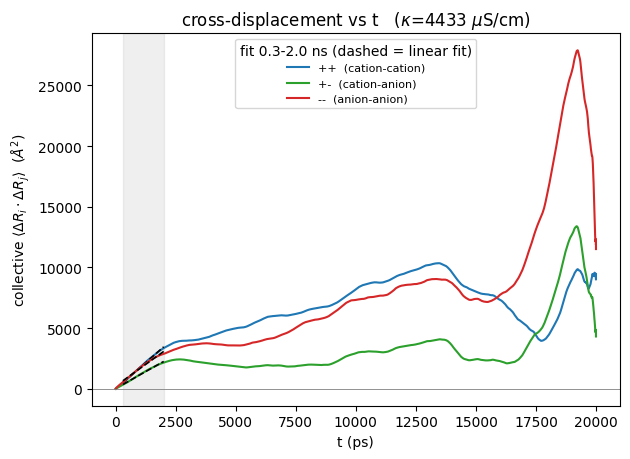

In [12]:
# ── Onsager post-processing: fit MSDs -> L_ij -> kappa / t_i / mobility ───────
# calculate_transport_coefficients MUST run first: it fits the MSDs to get L_ij,
# which conductivity / transference / mobility all consume. Self-contained from
# the `ons` object already in the kernel.
t = ons.results.times                              # lag time (ps)
dt_ps = float(t[1] - t[0])
dt_ns = dt_ps / 1000.0
n_lag = len(t)

fit_start_ns, fit_stop_ns = 0.3, 2.0              # diffusive-regime fit window (ns)
s = max(1, int(round(fit_start_ns / dt_ns)))
e = min(n_lag, int(round(fit_stop_ns / dt_ns)))
if e <= s:                                          # degenerate window -> fallback
    s, e = max(1, n_lag // 5), n_lag

ons.calculate_transport_coefficients(start=s, stop=e, scale="linear")
ons.calculate_conductivity()
ons.calculate_transference_numbers()
ons.calculate_electrophoretic_mobilities()

# unit conversions (defined in the Configuration cell)
kappa_uScm = ons.results.conductivity[0] * KAPPA_TO_SI * SI_TO_USCM
L_ij = ons.results.L_ij[0]                                  # (2,2) mol/(kJ.A.ps)
D_i  = ons.results.D_i[0] * D_TO_CM2_S                      # (2,) cm^2/s
t_i  = ons.results.transference_numbers[0]                 # (2,)
mu_i = ons.results.electrophoretic_mobilities[0]           # (2,)

print(f"fit window  : {fit_start_ns}-{fit_stop_ns} ns  (lag frames {s}-{e} of {n_lag})")
print(f"kappa       : {kappa_uScm:.1f} uS/cm  ({kappa_uScm/1e3:.3f} mS/cm)")
print(f"D(+ / -)    : {D_i[0]:.3e} / {D_i[1]:.3e} cm^2/s")
print(f"t+ / t-     : {t_i[0]:.3f} / {t_i[1]:.3f}")
print(f"mu+ / mu-   : {mu_i[0]:.3e} / {mu_i[1]:.3e}")
print(f"L_ij [mol/(kJ.A.ps)]:\n{L_ij}")

# ── cross square displacement vs t (collective <dR_i . dR_j>) + linear fit ────
# mdcraft stores msd_cross already divided by (2*ndim); undo to get raw CD.
cross = ons.results.msd_cross[:, 0] * (2 * NDIM)           # (3, nt): ++, +-, --
pair_lbl = {(0, 0): "++  (cation-cation)", (0, 1): "+-  (cation-anion)",
            (1, 1): "--  (anion-anion)"}
colors = ["tab:blue", "tab:green", "tab:red"]

fig, ax = plt.subplots(figsize=(6.4, 4.7))
for k, pr in enumerate(ons.results.pairs):
    y = cross[k]
    ax.plot(t, y, lw=1.5, color=colors[k % 3], label=pair_lbl.get(tuple(pr), str(pr)))
    coef = np.polyfit(t[s:e], y[s:e], 1)                   # linear fit over window
    ax.plot(t[s:e], np.polyval(coef, t[s:e]), "--", lw=1.2, color="k")
ax.axvspan(t[s], t[e - 1], color="grey", alpha=0.12)
ax.axhline(0, color="grey", lw=0.6)
ax.set_xlabel("t (ps)")
ax.set_ylabel(r"collective $\langle \Delta R_i \cdot \Delta R_j \rangle$  ($\AA^2$)")
ax.set_title(rf"cross-displacement vs t   ($\kappa$={kappa_uScm:.0f} $\mu$S/cm)")
ax.legend(fontsize=8, title=f"fit {fit_start_ns}-{fit_stop_ns} ns (dashed = linear fit)")
fig.tight_layout()
plt.show()

in-window (2.0-19.0 ns) mean log-log slope (target ~1):
  self +    : 0.94
  self -    : 0.95
  coll ++   : 0.34
  coll |+-| : 0.41
  coll --   : 0.75


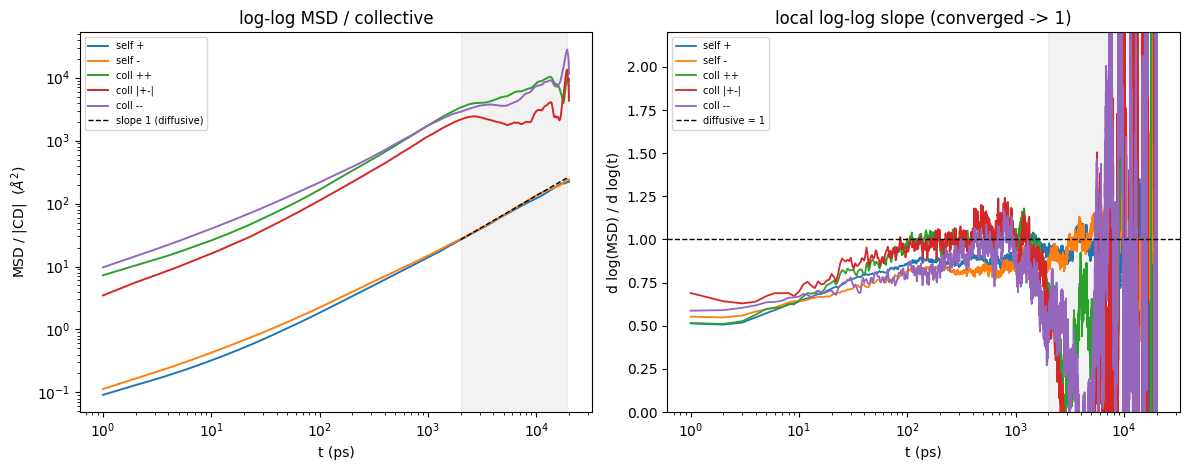

In [13]:
# ── convergence check: log-log MSD slopes (diffusive target = 1) ──────────────
# In the diffusive regime MSD ~ t, so d(log MSD)/d(log t) -> 1.
#   slope ~ 2 : ballistic (very short t)
#   slope < 1 : sub-diffusive (caging) -> NOT converged, fit window too early
#   slope ~ 1 : diffusive -> L_ij / D_i are trustworthy here
t        = ons.results.times                            # ps
self_msd = ons.results.msd_self[:, 0]                   # (2, nt): self +, self -
cross    = ons.results.msd_cross[:, 0] * (2 * NDIM)     # (3, nt): ++, +-, --

# fit window (ns) -> lag-frame indices
dt_ns = (t[1] - t[0]) / 1000.0
fit_start_ns, fit_stop_ns = 2.0, 19.0
s = max(1, int(round(fit_start_ns / dt_ns)))
e = min(len(t), int(round(fit_stop_ns / dt_ns)))
if e <= s:
    s, e = max(1, len(t) // 5), len(t)

# curves to check (collective +- can be negative -> use |.| for the log slope)
curves = [("self +",   self_msd[0],        "tab:blue"),
          ("self -",   self_msd[1],        "tab:orange"),
          ("coll ++",  cross[0],           "tab:green"),
          ("coll |+-|",np.abs(cross[1]),   "tab:red"),
          ("coll --",  cross[2],           "tab:purple")]
pos_t = t > 0                                            # drop t=0 for log

fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))

# panel 1: log-log curves + slope-1 guide
for lab, y, c in curves:
    m = pos_t & (np.abs(y) > 0)
    ax[0].loglog(t[m], np.abs(y[m]), color=c, lw=1.4, label=lab)
y0 = np.abs(self_msd[0])[s]
ax[0].loglog(t[s:e], y0 * (t[s:e] / t[s]), "k--", lw=1.0, label="slope 1 (diffusive)")
ax[0].axvspan(t[s], t[e - 1], color="grey", alpha=0.1)
ax[0].set(xlabel="t (ps)", ylabel=r"MSD / |CD|  ($\AA^2$)", title="log-log MSD / collective")
ax[0].legend(fontsize=7)

# panel 2: local log-log slope vs t (converged -> plateau at 1)
print(f"in-window ({fit_start_ns}-{fit_stop_ns} ns) mean log-log slope (target ~1):")
for lab, y, c in curves:
    yy = np.abs(y)
    m = pos_t & (yy > 0)
    slope_local = np.gradient(np.log(yy[m]), np.log(t[m]))
    ax[1].semilogx(t[m], slope_local, color=c, lw=1.3, label=lab)
    win = np.zeros(len(t), bool); win[s:e] = True; win &= m
    sl = np.polyfit(np.log(t[win]), np.log(yy[win]), 1)[0]
    print(f"  {lab:10s}: {sl:.2f}")
ax[1].axhline(1.0, color="k", ls="--", lw=1.0, label="diffusive = 1")
ax[1].axvspan(t[s], t[e - 1], color="grey", alpha=0.1)
ax[1].set(xlabel="t (ps)", ylabel="d log(MSD) / d log(t)", ylim=(0, 2.2),
          title="local log-log slope (converged -> 1)")
ax[1].legend(fontsize=7)
fig.tight_layout(); plt.show()

N_blocks = 5  (block length 4.0 ns)   fit 0.3-2.0 ns
kappa = 2359 +/- 1478 uS/cm   (2.359 +/- 1.478 mS/cm)
  per-block : [3088. -252. 2250. 4241. 2471.]
  rel.spread: 63%   (large -> Onsager kappa not converged on this single run)


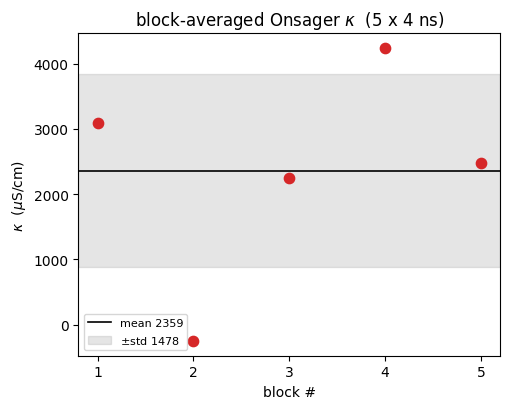

In [16]:
# ── block-averaged Onsager kappa: error bar from a single trajectory ──────────
# Split the (COM-removed) trajectory into N_BLOCKS chunks, fit each on the
# diffusive window, and report kappa = mean +/- std. A large spread vs the mean
# means the full Onsager kappa is NOT converged on this single run -> needs more
# independent data (replicas) or a longer trajectory. Uses ion_pos_c from the
# COM-removal cell; kappa is COM-invariant so lab vs centered give the same value.
N_BLOCKS = 5
FIT_START_NS, FIT_STOP_NS = 0.3, 2.0            # must be < block length (= total / N_BLOCKS)

u_blk = mda.Universe.empty(n_at, n_residues=n_at,
                           atom_resindex=np.arange(n_at), trajectory=True)
u_blk.add_TopologyAttr("name", ["NA"] * n_na + ["AN"] * n_an)
u_blk.load_new(ion_pos_c.astype(np.float32), format=MemoryReader)

ons_blk = Onsager([u_blk.atoms[:n_na], u_blk.atoms[n_na:]], groupings="atoms",
                  temperature=TEMPERATURE_K, charges=[1.0, -1.0],
                  dimensions=dims, dt=dt_ps, n_blocks=N_BLOCKS,
                  unwrap=False, center=False, fft=True, verbose=False)
ons_blk.run()

tb = ons_blk.results.times                      # per-block lag time (ps)
dtb_ns = (tb[1] - tb[0]) / 1000.0
block_ns = len(tb) * dtb_ns
sb = max(1, int(round(FIT_START_NS / dtb_ns)))
eb = min(len(tb), int(round(FIT_STOP_NS / dtb_ns)))

ons_blk.calculate_transport_coefficients(start=sb, stop=eb, scale="linear")
ons_blk.calculate_conductivity()

kappa_blocks = np.asarray(ons_blk.results.conductivity) * KAPPA_TO_SI * SI_TO_USCM  # (N_BLOCKS,)
km, ks = kappa_blocks.mean(), kappa_blocks.std()
print(f"N_blocks = {N_BLOCKS}  (block length {block_ns:.1f} ns)   fit {FIT_START_NS}-{FIT_STOP_NS} ns")
print(f"kappa = {km:.0f} +/- {ks:.0f} uS/cm   ({km/1e3:.3f} +/- {ks/1e3:.3f} mS/cm)")
print(f"  per-block : {kappa_blocks.round(0)}")
print(f"  rel.spread: {ks/abs(km)*100:.0f}%   "
      f"(large -> Onsager kappa not converged on this single run)")

# per-block scatter + mean/std band
fig, ax = plt.subplots(figsize=(5.2, 4.2))
ax.scatter(range(1, N_BLOCKS + 1), kappa_blocks, s=55, color="tab:red", zorder=3)
ax.axhline(km, color="k", lw=1.2, label=f"mean {km:.0f}")
ax.axhspan(km - ks, km + ks, color="grey", alpha=0.2, label=f"$\\pm$std {ks:.0f}")
ax.set(xlabel="block #", ylabel=r"$\kappa$  ($\mu$S/cm)",
       title=f"block-averaged Onsager $\\kappa$  ({N_BLOCKS} x {block_ns:.0f} ns)")
ax.set_xticks(range(1, N_BLOCKS + 1))
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()